# **BTS Spotify Data Engineering Final Project**

In honor of everyone's Spotify Wrapped coming out, the goal of this project will be to examine my top artist of the year and my favorite artist of all time - BTS! I've been a BTS fan since around August of 2015 (the summer before sixth grade!), and I've witnessed their tremendous growth as artists throughout the years.

I thought it'd be interesting to explore their present-day popularity, as well as their most streamed songs on Spotify. The end goal of the project will be to determine which of their top songs have made it to the "Billions Club" (songs with over 1 billion streams), and which songs are getting close, including a projection of how much longer it might take them to do so.

This notebook will walk through the entire data engineering pipeline:

1. Extract, Transform, Load (ETL): Fetching data from the Spotify API and a local CSV, cleaning and merging it, and engineering new features.

2. Deeper Analysis: Exploring song momentum and correlations within the data.

3. Visualization: Creating insightful plots to tell the story of the data.

4. Database Storage: Loading the final, cleaned data into a local SQLite database.

5. Conclusion: Summarizing the key findings and discussing potential next steps.

Let's get started! 🎵

# Part 1: Data Sourcing & Preparation (ETL) 🧹

This section covers the core ETL process. We'll start by setting up the environment, then use a custom Python class to handle all data fetching, cleaning, and transformation logic in a clean, reusable way.

**Environment Setup**

First, we'll mount the Google Drive to manage our project files and install the necessary spotipy library.

In [144]:
# Mount Google Drive to access project files
import os, sys
from google.colab import drive
drive.mount('/content/mnt')

# Create a symbolic link for easier path management
nb_path = '/content/notebooks'
if not os.path.exists(nb_path):
    os.symlink('/content/mnt/My Drive/Colab Notebooks', nb_path)
sys.path.insert(0, nb_path)

Drive already mounted at /content/mnt; to attempt to forcibly remount, call drive.mount("/content/mnt", force_remount=True).


In [145]:
# Install the Spotipy library for accessing the Spotify API
!pip install --target=$nb_path spotipy -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


**The BTSDataPipeline Class**

To keep our code organized and professional, we'll encapsulate the entire data processing workflow into a single class. This class will handle:

• Securely connecting to the Spotify API using secrets.

• Fetching artist information and top track data.

• Reading and cleaning stream count data from a local CSV file.

• Merging the two data sources.

• Engineering new features like momentum_score to provide deeper insights.

In [146]:
# Data Pipeline Class
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from google.colab import userdata
from datetime import datetime
import numpy as np

class BTSDataPipeline:
    def __init__(self):
        """Initializes the pipeline and securely connects to the Spotify API."""
        try:
            client_id = userdata.get('SPOTIPY_CLIENT_ID')
            client_secret = userdata.get('SPOTIPY_CLIENT_SECRET')
        except userdata.SecretNotFoundError:
            raise Exception("Please create Colab secrets for 'SPOTIPY_CLIENT_ID' and 'SPOTIPY_CLIENT_SECRET'.")

        auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
        self.sp = spotipy.Spotify(client_credentials_manager=auth_manager)
        self.artist_uri = 'spotify:artist:3Nrfpe0tUJi4K4DXYWgMUX'


    def fetch_spotify_data(self):
        """Fetches top tracks with release dates and popularity from the Spotify API."""
        artist_json = self.sp.artist(self.artist_uri)
        artist_info = {
            'artist_name': artist_json['name'],
            'artist_id': artist_json['id'],
            'followers': artist_json['followers']['total'],
            'genre': artist_json['genres'][0]
        }
        artist_info_df = pd.DataFrame([artist_info])

        artist_top_tracks_json = self.sp.artist_top_tracks(self.artist_uri)
        top_tracks_df = pd.json_normalize(artist_top_tracks_json['tracks'])

        # Keep essential columns, including release_date and track popularity
        top_tracks_df = top_tracks_df[['id', 'name', 'popularity', 'album.release_date']]
        top_tracks_df.columns = ['track_id', 'track_name', 'track_popularity', 'release_date']

        return artist_info_df, top_tracks_df


    def fetch_kworb_data(self, csv_path="BTS - Spotify Top Songs.csv"):
        """Reads and cleans the stream count data from the local CSV file."""
        df = pd.read_csv(csv_path)
        df.columns = ['track_name', 'total_streams', 'daily_streams']
        df['track_name'] = df['track_name'].str.strip('*').str.strip()
        df.loc[df['track_name'] == 'Boy With Luv (Feat. Halsey)', 'track_name'] = 'Boy With Luv (feat. Halsey)'

        # Convert stream columns to numeric, removing commas
        df['total_streams'] = pd.to_numeric(df['total_streams'].str.replace(',', ''))
        df['daily_streams'] = pd.to_numeric(df['daily_streams'].str.replace(',', ''))

        return df


    def run(self):
        """Executes the full pipeline: fetch, clean, merge, and feature engineering."""
        artist_info_df, top_tracks_df = self.fetch_spotify_data()
        streams_df = self.fetch_kworb_data()

        # Merge Spotify data with stream data
        merged_df = pd.merge(top_tracks_df, streams_df, on='track_name', how='inner')

        # Add artist info to every row
        for col in artist_info_df.columns:
            merged_df[col] = artist_info_df[col].iloc[0]

        # --- Feature Engineering for Momentum Analysis ---
        merged_df['release_date'] = pd.to_datetime(merged_df['release_date'])
        merged_df['days_since_release'] = (datetime.now() - merged_df['release_date']).dt.days
        merged_df['avg_daily_streams'] = (merged_df['total_streams'] / merged_df['days_since_release']).round()
        # Calculate momentum: ratio of current daily streams to lifetime average
        merged_df['momentum_score'] = (merged_df['daily_streams'] / merged_df['avg_daily_streams']).round(2)

        # Sort and reorder columns
        final_df = merged_df.sort_values(by='total_streams', ascending=False).reset_index(drop=True)
        column_order = [
            'artist_name', 'track_name', 'release_date', 'total_streams', 'daily_streams',
            'avg_daily_streams', 'momentum_score', 'track_popularity', 'followers', 'genre'
        ]

        return final_df[column_order]


**Executing the Pipeline**

With the BTSDataPipeline class defined, our main workflow becomes incredibly clean. We just need to instantiate the class and call the run() method to get our final, analysis-ready DataFrame.

NOTE: Must have SPOTIPY_CLIENT_ID and SPOTIPY_CLIENT_SECRET saved as Colab Secrets, and BTS - Spotify Top Songs.csv file uploaded to Colab session's file directory.

In [147]:
pipeline = BTSDataPipeline()
BTS_songs = pipeline.run()
BTS_songs.head(10)

,artist_name,track_name,release_date,total_streams,daily_streams,avg_daily_streams,momentum_score,track_popularity,followers,genre
0,BTS,Dynamite,2020-11-20,2130562214,475419,1192924.0,0.40,79,80988351,k-pop
1,BTS,My Universe,2021-10-15,1512971721,365387,1038416.0,0.35,76,80988351,k-pop
2,BTS,Butter,2022-06-10,1391090445,248640,1141173.0,0.22,74,80988351,k-pop
3,BTS,Boy With Luv (feat. Halsey),2019-04-12,1309755727,292279,551708.0,0.53,76,80988351,k-pop
4,BTS,Left and Right (Feat. Jung Kook of BTS),2022-10-06,1119412623,233696,1016724.0,0.23,72,80988351,k-pop
5,BTS,FAKE LOVE,2018-05-18,1012413335,287749,374552.0,0.77,77,80988351,k-pop
6,BTS,Life Goes On,2020-11-20,842578797,475797,471769.0,1.01,78,80988351,k-pop
7,BTS,Permission to Dance,2021-07-23,762182208,180617,494602.0,0.37,74,80988351,k-pop
8,BTS,DNA,2017-09-18,722721582,209049,245406.0,0.85,73,80988351,k-pop
9,BTS,Run BTS,2022-06-10,550887877,207567,451918.0,0.46,75,80988351,k-pop


**Feature Engineering: Song Momentum**

The "daily streams" data is a snapshot. A more insightful metric is momentum, which tells us how a song is performing now compared to its lifetime average.

Average Daily Streams: total streams divided by the number of days since the song's release.

Momentum Score: ratio of current daily streams to the average daily streams.
*   A score > 1.0 suggests the song is currently more popular than its lifetime average (gaining momentum, perhaps due to social media trends).
*   A score < 1.0 suggests the song's peak has passed, but it maintains consistent streams.

Looking at the new momentum_score column in our dataframe, we can see that "Life Goes On" has an incredibly high score! This indicates it's being streamed far more frequently right now than its historical average, possibly due to recent trends on social media or its timeless message. This is a much more interesting insight than just looking at the raw daily stream count.

# Part 2: Data Analysis & Storytelling 🎵

The initial analysis was great for identifying which songs are on the path to the "Billions Club." Now, let's dive deeper to understand the momentum behind these songs and explore other interesting relationships in the data.

**Correlation Analysis: Spotify's Popularity vs. Actual Streams**

Spotify assigns each track a popularity score from 0 to 100. But does this internal metric actually reflect real-world performance? Let's find out by plotting it against the daily_streams.

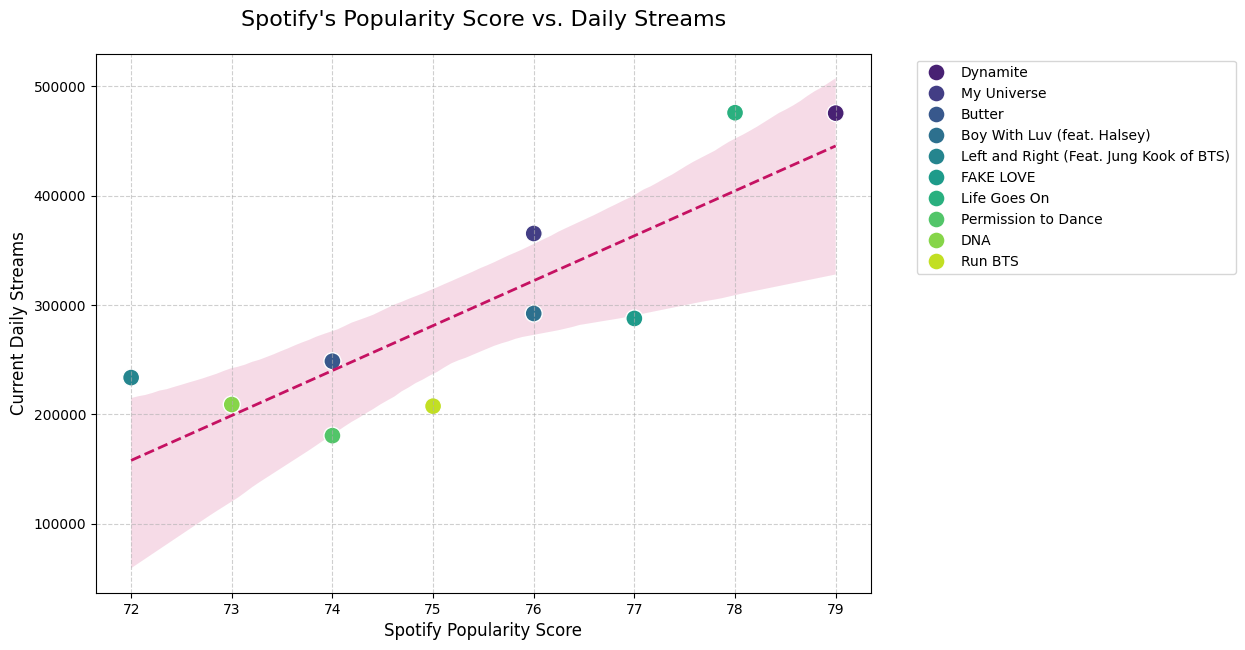

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.regplot(data=BTS_songs, x='track_popularity', y='daily_streams', scatter=False, color='#C51162', line_kws={"lw":2, "ls":"--"})
sns.scatterplot(data=BTS_songs, x='track_popularity', y='daily_streams', hue='track_name', s=150, palette='viridis')

plt.title("Spotify's Popularity Score vs. Daily Streams", fontsize=16, pad=20)
plt.xlabel("Spotify Popularity Score", fontsize=12)
plt.ylabel("Current Daily Streams", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The upward trend of the regression line clearly shows a strong positive correlation. As Spotify's internal popularity score increases, the actual number of daily streams also tends to increase significantly. This confirms that their metric is a reliable indicator of a song's current performance.

# Part 3: Data Visualizations & Presentation ✨
Now, let's create some more compelling visualizations to better tell our story.

**Total Streams for Top BTS Songs**

First, a clean visualization of the total stream counts for BTS's top tracks.

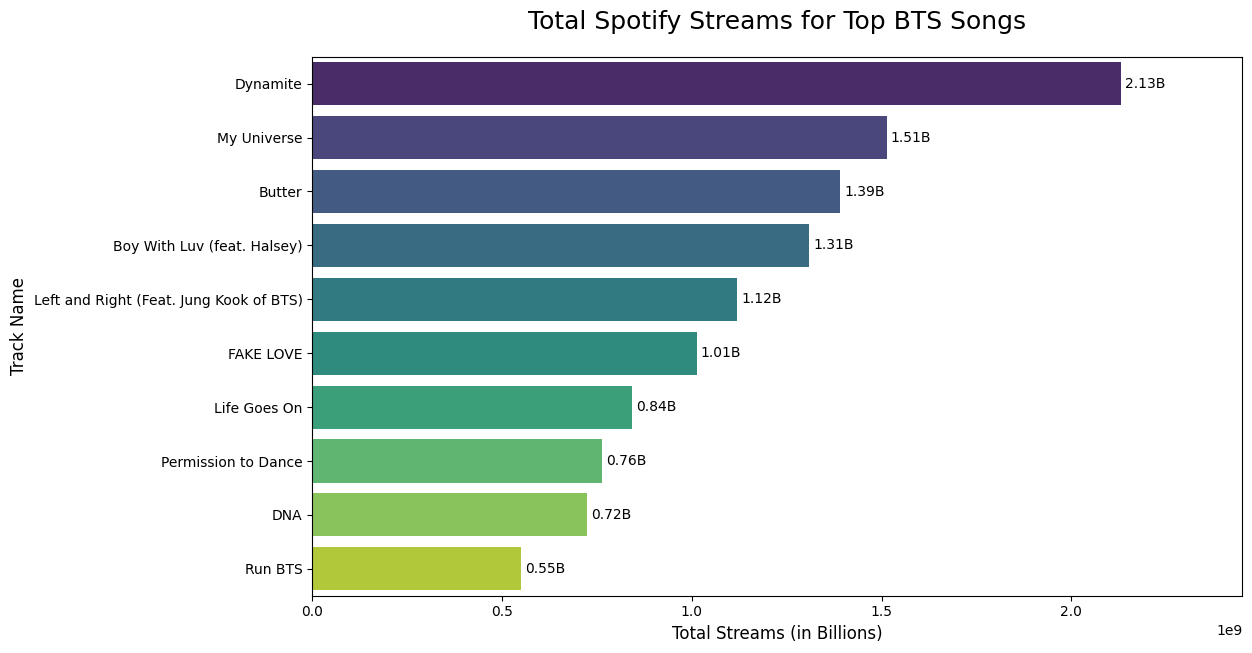

In [149]:
# Create a copy for plotting to avoid SettingWithCopyWarning
plot_df = BTS_songs.copy()
plot_df['total_streams_numeric'] = pd.to_numeric(plot_df['total_streams'])

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=plot_df, x='total_streams_numeric', y='track_name', palette='viridis', hue='track_name', dodge=False)
plt.legend([],[], frameon=False) # Hide legend for hue

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x/1e9:.2f}B', padding=3, fontsize=10)

plt.title('Total Spotify Streams for Top BTS Songs', fontsize=18, pad=20)
plt.xlabel('Total Streams (in Billions)', fontsize=12)
plt.ylabel('Track Name', fontsize=12)
ax.set_xlim(right=plot_df['total_streams_numeric'].max() * 1.15) # Give space for labels
plt.show()

**Road to the Billions Club 🔥**

A table is informative, but a "progress bar" style chart is much more intuitive for showing how close each song is to the 1 billion stream milestone.

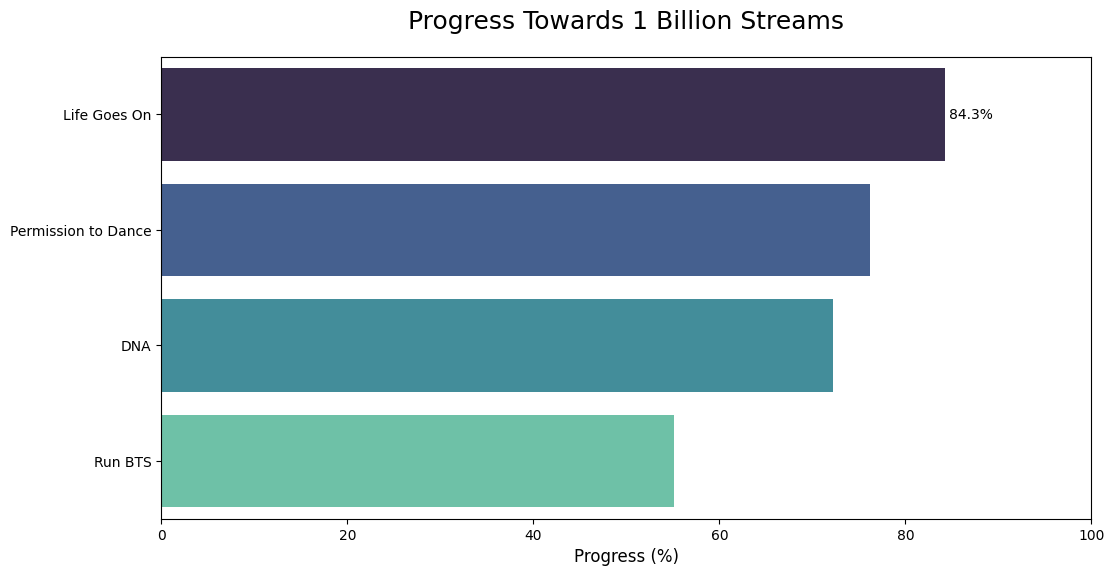

In [150]:
# Create the dataframe for songs on the road to a billion
road_to_billions = BTS_songs[BTS_songs['total_streams'] < 1_000_000_000].copy()

# Calculate progress percentage
road_to_billions['progress_pct'] = (road_to_billions['total_streams'] / 1_000_000_000) * 100

# Plotting the progress bars
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=road_to_billions.sort_values('progress_pct', ascending=False),
                 x='progress_pct', y='track_name', palette='mako', hue='track_name', dodge=False)
plt.legend([],[], frameon=False) # Hide legend for hue

ax.set_xlim(0, 100) # Set x-axis from 0% to 100%
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=10)

plt.title('Progress Towards 1 Billion Streams', fontsize=18, pad=20)
plt.xlabel('Progress (%)', fontsize=12)
plt.ylabel('')
plt.show()

"Life Goes On" is the next song in line to join the Billions Club, already over 84% of the way there!

**Years to Reach 1 Billion Streams (Projection)**

This visualization shows our projection for how long it might take the remaining songs to reach 1 billion streams, based on their current daily rates.

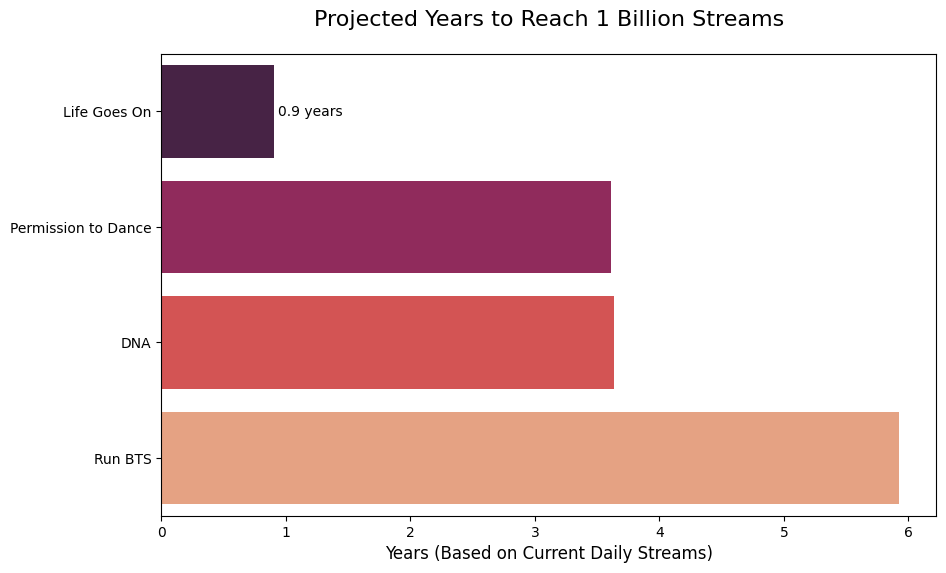

In [151]:
# Calculate projection
road_to_billions['remaining_streams'] = 1_000_000_000 - road_to_billions['total_streams']
road_to_billions['years_to_1B'] = road_to_billions['remaining_streams'] / (road_to_billions['daily_streams'] * 365)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=road_to_billions.sort_values('years_to_1B'),
                 x='years_to_1B', y='track_name', palette='rocket', hue='track_name', dodge=False)
plt.legend([],[], frameon=False) # Hide legend for hue


ax.bar_label(ax.containers[0], fmt='%.1f years', padding=3, fontsize=10)
plt.title('Projected Years to Reach 1 Billion Streams', fontsize=16, pad=20)
plt.xlabel('Years (Based on Current Daily Streams)', fontsize=12)
plt.ylabel('')
plt.show()

# Part 4: Pushing to a SQL database (SQLite version) 📦

With our analysis complete, the final step is to load the clean, processed data into a structured database for storage and future use. We'll use SQLite, a serverless, file-based database engine that's built into Python.

In [152]:
import sqlalchemy

# 1. Create a connection engine to a local SQLite file
# Creates a file named 'bts_spotify.db' in Colab environment
engine = sqlalchemy.create_engine('sqlite:///bts_spotify.db')

# 2. Push final dataframes to SQL tables.
# The `to_sql` method handles creating the table and inserting the data.
BTS_songs.to_sql('bts_songs_enriched', engine, if_exists='replace', index=False)
road_to_billions.to_sql('road_to_billions', engine, if_exists='replace', index=False)

print("Data successfully loaded into 'bts_spotify.db'")

Data successfully loaded into 'bts_spotify.db'


**Verifying the Data with SQL Queries**

Now we can use standard SQL queries to read the data back from our new database to confirm it was loaded correctly.

In [153]:
# Query 1: Select the song with the highest momentum score
sq_momentum = "SELECT track_name, momentum_score FROM bts_songs_enriched ORDER BY momentum_score DESC LIMIT 1;"
momentum_df = pd.read_sql(sq_momentum, engine)
print("--- Song with Highest Momentum ---")
print(momentum_df)

--- Song with Highest Momentum ---
     track_name  momentum_score
0  Life Goes On            1.01


In [154]:
# Query 2: Select the next song projected to reach 1 billion streams
sq_next_billion = "SELECT track_name, years_to_1B FROM road_to_billions ORDER BY years_to_1B ASC LIMIT 1;"
next_billion_df = pd.read_sql(sq_next_billion, engine)
print("--- Next Song to Reach 1B Streams ---")
print(next_billion_df)

--- Next Song to Reach 1B Streams ---
     track_name  years_to_1B
0  Life Goes On      0.90646


# Part 5: Conclusion & Next Steps 🔍

This project successfully created a data pipeline to analyze BTS's Spotify performance. We started by fetching data from the Spotify API and a secondary web source, cleaning and merging it, engineering new features, and loading it into a local SQLite database for querying.

**Key Findings:**

1. Billions Club: BTS currently has six songs in their top 10 that have surpassed one billion streams on Spotify.

2. The Next Contender: "Life Goes On" is the clear front-runner to be the next song to reach this milestone, projected to do so in less than a year.

3. Song Momentum: "Life Goes On" also has the highest momentum, meaning its current daily stream rate is significantly higher than its lifetime average, indicating a recent surge in popularity.

4. Metric Correlation: Spotify's internal popularity score shows a strong positive correlation with actual daily stream counts, confirming its validity as a performance indicator.

**Limitations & Next Steps:**

* Static Data: The stream counts are from a single point in time (collected on 10/11/2025). A more advanced project would involve setting up a script to fetch this data daily to track trends over time.

* Simple Projection: The "years to 1B" calculation is a linear projection. In reality, a song's popularity fluctuates.

* Audio Feature Analysis: The Spotify API provides rich "audio features" for each track (e.g., danceability, energy, acousticness). A great next step would be to analyze these features to see if there are common characteristics among the most-streamed songs.